

git# Fase 0 — Auditoria, qualidade e semântica do alvo radar

Este notebook **não executa a varredura pesada do Zarr**. A varredura é realizada pelo script `scripts/00_audit_dataset.py`, que lê o dataset em lotes e grava resultados reduzidos em `analysis_outputs/00_quality/`.

Nesta versão, a Fase 0 também audita explicitamente o caminho **PNG do radar → legenda RGB → cache `.npy` → patch → `target` do Zarr**. Quando o diretório do cache é informado, o script compara amostras do Zarr diretamente contra os `.npy` correspondentes.

O objetivo é responder, antes de qualquer análise meteorológica ou treinamento:

- a estrutura do Zarr está consistente?
- a ordem e o número de canais estão corretos?
- qual é a cobertura temporal real entre 2011 e 2024?
- qual é a geometria espacial efetiva dos patches?
- há NaN/Inf inesperado nas entradas?
- como o cache do radar é representado numericamente?
- o `target` armazenado realmente reproduz `log1p(clip(cache, 0, +∞))`?
- a máscara armazenada reproduz `isfinite(cache_patch)`?
- a unidade física do produto radar está declarada pelo builder ou ainda precisa ser confirmada na fonte original?

> **Regra científica:** o builder chama o campo do cache de `reflectivity`, mas não declara a unidade física como `dBZ`. Portanto, este notebook separa o que é comprovado pelo código do que ainda depende da documentação original do produto radar.


## 0. Execução do auditor

A execução completa recomendada, a partir da raiz do projeto, é:

```bash
export CORRDIFF_RADAR_CACHE_DIR=/caminho/para/o/cache_do_radar

python scripts/00_audit_dataset.py \
  --dataset-dir datasets/corrdiff_2011_2024 \
  --radar-cache-dir "$CORRDIFF_RADAR_CACHE_DIR" \
  --output-dir analysis_outputs/00_quality \
  --batch-samples 512 \
  --quantile-sample-values 200000 \
  --radar-cache-file-sample 128 \
  --radar-target-validation-samples 256 \
  --overwrite
```

Também é possível definir somente `CORRDIFF_RADAR_CACHE_DIR`; o script usa essa variável quando `--radar-cache-dir` não é informado.

Para validar rapidamente caminhos e estrutura sem percorrer todos os pixels do Zarr:

```bash
python scripts/00_audit_dataset.py \
  --dataset-dir datasets/corrdiff_2011_2024 \
  --radar-cache-dir "$CORRDIFF_RADAR_CACHE_DIR" \
  --output-dir analysis_outputs/00_quality_quick \
  --radar-cache-file-sample 32 \
  --radar-target-validation-samples 64 \
  --quick \
  --overwrite
```

A execução `full` calcula contagens de NaN/Inf, média, desvio padrão, mínimo e máximo de forma exata sobre o Zarr. Os quantis são aproximados por amostragem controlada. A auditoria do cache não enumera todos os arquivos de 2 minutos: ela amostra arquivos associados a timestamps efetivamente representados no dataset, evitando um `glob` de milhões de arquivos.


In [7]:
from pathlib import Path
import json
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)

# Se o JupyterLab foi iniciado na raiz do projeto, os defaults abaixo funcionam.
# Você também pode definir CORRDIFF_DATASET_DIR e CORRDIFF_QUALITY_DIR no shell.
DATASET_DIR = Path(os.environ.get("CORRDIFF_DATASET_DIR", "../datasets/corrdiff_2011_2024"))
QUALITY_DIR = Path(os.environ.get("CORRDIFF_QUALITY_DIR", "../analysis_outputs/00_quality"))

print("DATASET_DIR:", DATASET_DIR.resolve())
print("QUALITY_DIR:", QUALITY_DIR.resolve())

DATASET_DIR: /home/vsantos/repositories/rionowcastdf/datasets/corrdiff_2011_2024
QUALITY_DIR: /home/vsantos/repositories/rionowcastdf/analysis_outputs/00_quality


In [8]:
required_files = [
    QUALITY_DIR / "dataset_summary.json",
    QUALITY_DIR / "audit_warnings.json",
    QUALITY_DIR / "radar_target_semantics.json",
    QUALITY_DIR / "radar_legend_mapping.parquet",
    QUALITY_DIR / "yearly_coverage.parquet",
    QUALITY_DIR / "monthly_coverage.parquet",
    QUALITY_DIR / "hourly_coverage.parquet",
    QUALITY_DIR / "temporal_coverage.parquet",
]

missing = [str(path) for path in required_files if not path.exists()]
if missing:
    raise FileNotFoundError(
        "Execute scripts/00_audit_dataset.py antes deste notebook. Arquivos ausentes:\n- "
        + "\n- ".join(missing)
    )

with (QUALITY_DIR / "dataset_summary.json").open("r", encoding="utf-8") as f:
    summary = json.load(f)

with (QUALITY_DIR / "audit_warnings.json").open("r", encoding="utf-8") as f:
    audit_messages = json.load(f)

with (QUALITY_DIR / "radar_target_semantics.json").open("r", encoding="utf-8") as f:
    radar_semantics = json.load(f)

yearly = pd.read_parquet(QUALITY_DIR / "yearly_coverage.parquet")
monthly = pd.read_parquet(QUALITY_DIR / "monthly_coverage.parquet")
hourly = pd.read_parquet(QUALITY_DIR / "hourly_coverage.parquet")
temporal = pd.read_parquet(QUALITY_DIR / "temporal_coverage.parquet")
radar_legend = pd.read_parquet(QUALITY_DIR / "radar_legend_mapping.parquet")

channel_path = QUALITY_DIR / "channel_summary.parquet"
missing_path = QUALITY_DIR / "missing_data.parquet"
patch_position_path = QUALITY_DIR / "patch_position_counts.parquet"
radar_cache_stats_path = QUALITY_DIR / "radar_cache_sample_statistics.parquet"
radar_mapping_path = QUALITY_DIR / "radar_target_mapping_validation.parquet"

channel_summary = pd.read_parquet(channel_path) if channel_path.exists() else pd.DataFrame()
missing_data = pd.read_parquet(missing_path) if missing_path.exists() else pd.DataFrame()
patch_positions = pd.read_parquet(patch_position_path) if patch_position_path.exists() else pd.DataFrame()
radar_cache_stats = pd.read_parquet(radar_cache_stats_path) if radar_cache_stats_path.exists() else pd.DataFrame()
radar_mapping = pd.read_parquet(radar_mapping_path) if radar_mapping_path.exists() else pd.DataFrame()

print("Status do audit:", summary.get("status"))
print("Modo:", summary.get("audit_mode"))
print("Tempo de execução (s):", round(summary.get("elapsed_seconds", 0), 2))
print("Cache radar:", summary.get("paths", {}).get("radar_cache_dir"))


Status do audit: PASS
Modo: full
Tempo de execução (s): 675.96
Cache radar: /home/vsantos/repositories/rionowcastdf/data/radar_cache


## 1. Resumo estrutural


In [9]:
dataset = summary["dataset"]
config = summary["configuration"]
temporal_summary = summary["temporal"]
patch_geometry = summary["patch_geometry"]

structural = pd.DataFrame(
    [
        ("Amostras (patches)", dataset.get("num_samples")),
        ("Canais de entrada", dataset.get("num_channels")),
        ("Shape input", str(dataset.get("input_shape"))),
        ("Shape target", str(dataset.get("target_shape"))),
        ("Shape mask", str(dataset.get("mask_shape"))),
        ("Dimensão amostral consistente", dataset.get("sample_dimension_consistent")),
        ("Transformação do target", dataset.get("target_transform")),
        ("Período configurado", f"{config.get('start_date')} → {config.get('end_date')}"),
        ("Frequência temporal", config.get("time_frequency")),
        ("Grade do radar", str(config.get("radar_grid_shape"))),
        ("Resolução do radar (km)", config.get("radar_resolution_km")),
        ("Patch size", config.get("patch_size")),
        ("Stride", config.get("stride")),
    ],
    columns=["Item", "Valor"],
)

display(structural)

,Item,Valor
0,Amostras (patches),1132464
1,Canais de entrada,12
2,Shape input,"[1132464, 12, 32, 32]"
3,Shape target,"[1132464, 1, 32, 32]"
4,Shape mask,"[1132464, 1, 32, 32]"
5,Dimensão amostral consistente,True
6,Transformação do target,log1p
7,Período configurado,2011-01-01T00:00:00 → 2024-12-31T23:00:00
8,Frequência temporal,1h
9,Grade do radar,"[70, 84]"


In [10]:
channels = pd.DataFrame(
    {
        "índice": range(len(dataset.get("channels", []))),
        "canal": dataset.get("channels", []),
    }
)
display(channels)

,índice,canal
0,0,tcwv
1,1,t2m
2,2,u10
3,3,v10
4,4,t_850
5,5,r_850
6,6,u_850
7,7,v_850
8,8,t_500
9,9,r_500


### Configuração esperada neste experimento

A configuração científica planejada é:

- **superfície:** `tcwv`, `t2m`, `u10`, `v10`;
- **850 hPa:** `t_850`, `r_850`, `u_850`, `v_850`;
- **500 hPa:** `t_500`, `r_500`, `u_500`, `v_500`;
- **12 canais ERA5** ao todo;
- **radar:** grade 70×84, resolução espacial de 2 km;
- **dataset:** frequência horária;
- **patches:** 32×32, stride 16.

A tabela acima é a fonte efetiva do Zarr/metadata e deve prevalecer sobre qualquer expectativa teórica.


## 2. Avisos e notas do auditor


In [11]:
warnings = audit_messages.get("warnings", [])
notes = audit_messages.get("notes", [])

if warnings:
    display(Markdown("### ⚠️ Avisos"))
    for item in warnings:
        display(Markdown(f"- **{item['code']}** — {item['message']}"))
else:
    display(Markdown("✅ **Nenhum aviso estrutural crítico foi produzido pelo auditor.**"))

if notes:
    display(Markdown("### Notas"))
    for item in notes:
        display(Markdown(f"- **{item['code']}** — {item['message']}"))

✅ **Nenhum aviso estrutural crítico foi produzido pelo auditor.**

### Notas

- **target_transform_log1p** — Stored target uses log1p. In the audited builder, the source cache is created from PNG RGB colors mapped to numerical radar-legend values and saved as float32; the builder itself does not declare the physical unit as dBZ. Direct cache -> target validation is performed when --radar-cache-dir is supplied.

- **temporal_gaps_present** — Dataset contains 28364 expected timestamps with no written patch; inspect temporal_coverage.parquet and builder counters.

- **patch_geometry_uncovered_edges** — Patch geometry covers 87.07% of the 70x84 radar grid. This follows directly from patch_size/stride and should be considered when reconstructing full fields.

- **radar_target_mapping_verified** — Directly reproduced cache -> Zarr target/mask for 256 sampled patches: isfinite mask + nan_to_num + clip(min=0) + log1p.

## 3. Cobertura temporal global


In [12]:
temporal_table = pd.DataFrame(
    [
        ("Timestamps esperados", temporal_summary.get("expected_timestamps")),
        ("Timestamps com pelo menos um patch", temporal_summary.get("available_timestamps")),
        ("Timestamps sem patch", temporal_summary.get("missing_timestamps")),
        ("Cobertura temporal", temporal_summary.get("coverage_ratio")),
        ("Primeiro timestamp observado", temporal_summary.get("first_observed_timestamp")),
        ("Último timestamp observado", temporal_summary.get("last_observed_timestamp")),
        ("Unidade detectada no Zarr", temporal_summary.get("timestamp_storage_unit_detected")),
    ],
    columns=["Métrica", "Valor"],
)
display(temporal_table)

coverage = temporal_summary.get("coverage_ratio")
if coverage is not None:
    print(f"Cobertura global: {coverage:.2%}")

,Métrica,Valor
0,Timestamps esperados,122736
1,Timestamps com pelo menos um patch,94372
2,Timestamps sem patch,28364
3,Cobertura temporal,0.768902
4,Primeiro timestamp observado,2011-01-17T18:00:00
5,Último timestamp observado,2024-12-31T23:00:00
6,Unidade detectada no Zarr,s


Cobertura global: 76.89%


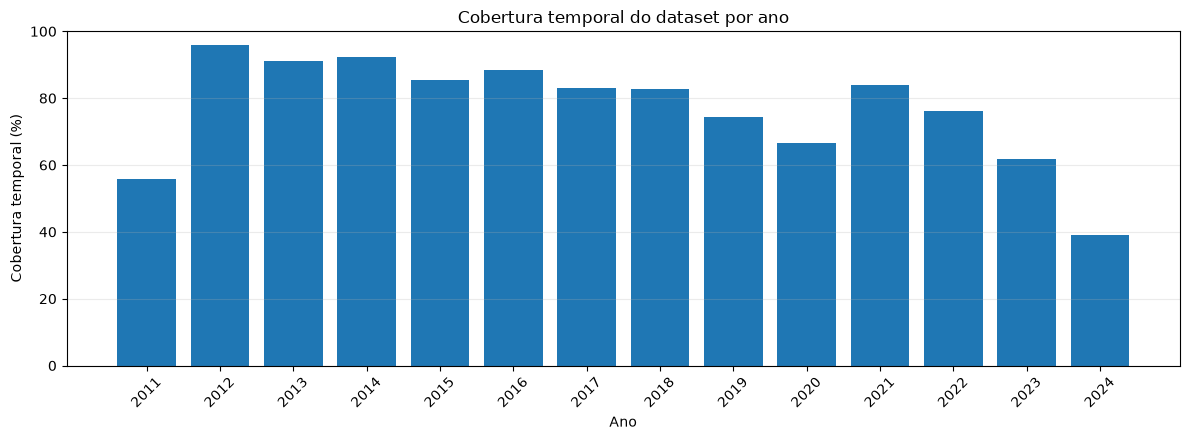

,year,expected_timestamps,available_timestamps,samples,missing_timestamps,coverage_ratio,mean_patches_per_available_timestamp
0,2011,8760,4896,58752,3864,0.558904,12.0
1,2012,8784,8417,101004,367,0.958219,12.0
2,2013,8760,7979,95748,781,0.910845,12.0
3,2014,8760,8095,97140,665,0.924087,12.0
4,2015,8760,7472,89664,1288,0.852968,12.0
5,2016,8784,7771,93252,1013,0.884677,12.0
6,2017,8760,7266,87192,1494,0.829452,12.0
7,2018,8760,7242,86904,1518,0.826712,12.0
8,2019,8760,6513,78156,2247,0.743493,12.0
9,2020,8784,5846,70152,2938,0.665528,12.0


In [13]:
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.bar(yearly["year"].astype(str), yearly["coverage_ratio"] * 100)
ax.set_ylim(0, 100)
ax.set_ylabel("Cobertura temporal (%)")
ax.set_xlabel("Ano")
ax.set_title("Cobertura temporal do dataset por ano")
ax.grid(axis="y", alpha=0.25)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

display(yearly)

**Interpretação:** quedas localizadas em um ano não devem ser interpretadas inicialmente como sinal meteorológico. Primeiro devem ser confrontadas com os contadores do builder (`missing_radar`, `missing_era5`, patches rejeitados) e com a disponibilidade do arquivo histórico do radar.


## 4. Cobertura mensal — procura por lacunas sistemáticas


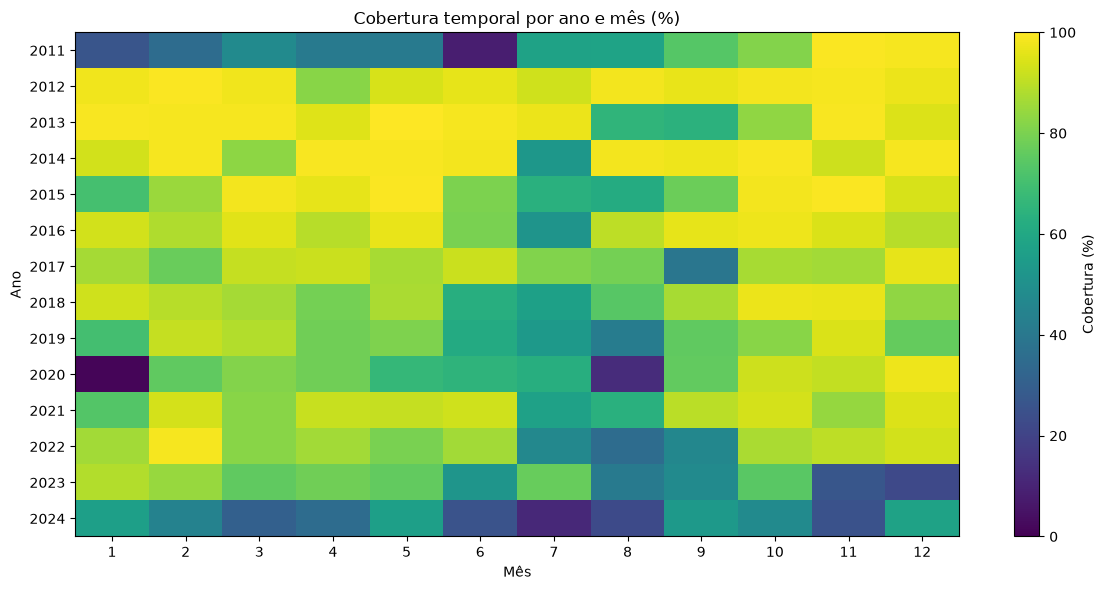

In [14]:
coverage_matrix = monthly.pivot(index="year", columns="month", values="coverage_ratio") * 100
coverage_matrix = coverage_matrix.reindex(columns=range(1, 13))

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(coverage_matrix.values, aspect="auto", vmin=0, vmax=100)
ax.set_title("Cobertura temporal por ano e mês (%)")
ax.set_xlabel("Mês")
ax.set_ylabel("Ano")
ax.set_xticks(range(12), range(1, 13))
ax.set_yticks(range(len(coverage_matrix.index)), coverage_matrix.index)
fig.colorbar(im, ax=ax, label="Cobertura (%)")
plt.tight_layout()
plt.show()

In [15]:
worst_months = monthly.sort_values(["coverage_ratio", "year", "month"]).head(24)
display(worst_months)

,year,month,expected_timestamps,available_timestamps,samples,missing_timestamps,coverage_ratio,mean_patches_per_available_timestamp
108,2020,1,744,11,132,733,0.014785,12.0
5,2011,6,720,60,720,660,0.083333,12.0
162,2024,7,744,86,1032,658,0.115591,12.0
115,2020,8,744,95,1140,649,0.127688,12.0
155,2023,12,744,163,1956,581,0.219086,12.0
163,2024,8,744,168,2016,576,0.225806,12.0
166,2024,11,720,180,2160,540,0.250000,12.0
161,2024,6,720,185,2220,535,0.256944,12.0
0,2011,1,744,195,2340,549,0.262097,12.0
154,2023,11,720,192,2304,528,0.266667,12.0


## 5. Cobertura por hora UTC


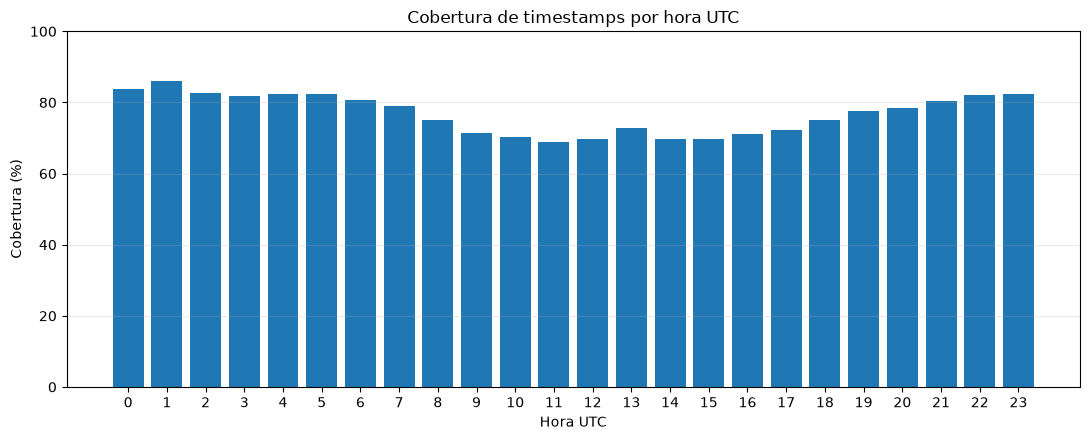

,hour_utc,expected_timestamps,available_timestamps,samples,coverage_ratio,mean_patches_per_available_timestamp
0,0,5114,4288,51456,0.838483,12.0
1,1,5114,4403,52836,0.860970,12.0
2,2,5114,4230,50760,0.827141,12.0
3,3,5114,4186,50232,0.818537,12.0
4,4,5114,4212,50544,0.823621,12.0
5,5,5114,4218,50616,0.824795,12.0
6,6,5114,4127,49524,0.807000,12.0
7,7,5114,4037,48444,0.789402,12.0
8,8,5114,3838,46056,0.750489,12.0
9,9,5114,3656,43872,0.714900,12.0


In [16]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(hourly["hour_utc"], hourly["coverage_ratio"] * 100)
ax.set_xticks(range(24))
ax.set_ylim(0, 100)
ax.set_xlabel("Hora UTC")
ax.set_ylabel("Cobertura (%)")
ax.set_title("Cobertura de timestamps por hora UTC")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

display(hourly)

**Por que isso importa:** uma cobertura muito diferente entre horas pode enviesar a análise posterior do ciclo diurno. Antes de concluir que determinada hora possui mais ou menos precipitação, precisamos saber se ela possui a mesma disponibilidade observacional.


## 6. Quantidade de patches por timestamp


,min,p25,median,mean,p75,max
0,12,12.0,12.0,12.0,12.0,12


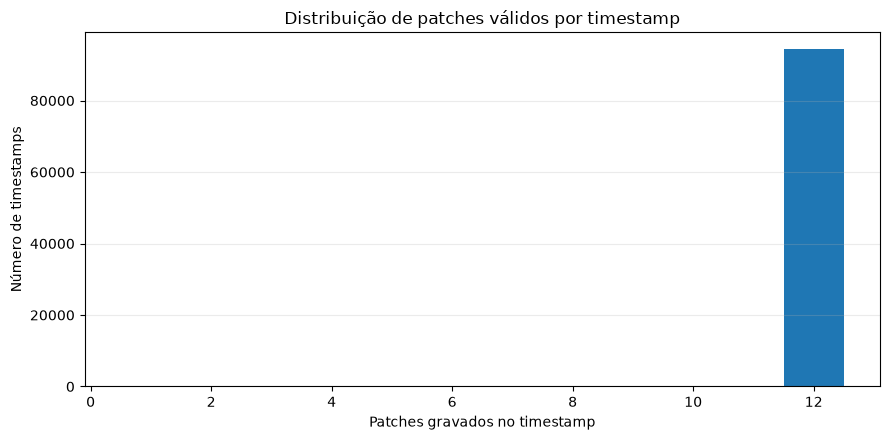

In [17]:
patch_stats = temporal_summary.get("patches_per_timestamp", {})
display(pd.DataFrame([patch_stats]))

available_temporal = temporal.loc[temporal["available"]].copy()
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(available_temporal["samples"], bins=np.arange(0.5, available_temporal["samples"].max() + 1.5, 1))
ax.set_xlabel("Patches gravados no timestamp")
ax.set_ylabel("Número de timestamps")
ax.set_title("Distribuição de patches válidos por timestamp")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

Para a grade 70×84 com `patch_size=32` e `stride=16`, a geometria convencional do builder produz no máximo **12 âncoras** por campo completo (3 posições verticais × 4 horizontais), antes dos filtros de validade.


## 7. Geometria espacial dos patches


,Métrica,Valor
0,Âncoras esperadas por campo,12.000000
1,Âncoras observadas,12.000000
2,Cobertura espacial esperada,0.870748
3,Cobertura espacial observada,0.870748


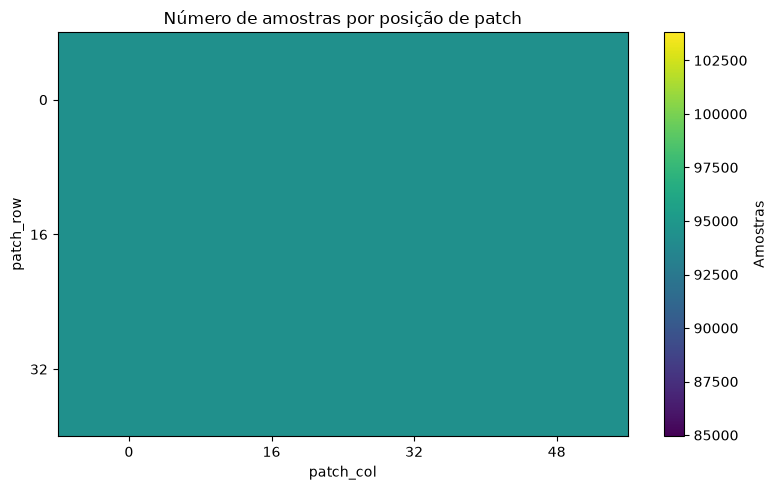

,patch_row,patch_col,samples
0,0,0,94372
1,0,16,94372
2,0,32,94372
3,0,48,94372
4,16,0,94372
5,16,16,94372
6,16,32,94372
7,16,48,94372
8,32,0,94372
9,32,16,94372


In [18]:
geometry_table = pd.DataFrame(
    [
        ("Âncoras esperadas por campo", patch_geometry.get("expected_patch_positions_per_full_field")),
        ("Âncoras observadas", patch_geometry.get("actual_unique_patch_positions")),
        ("Cobertura espacial esperada", patch_geometry.get("expected_spatial_coverage_ratio")),
        ("Cobertura espacial observada", patch_geometry.get("actual_spatial_coverage_ratio")),
    ],
    columns=["Métrica", "Valor"],
)
display(geometry_table)

if not patch_positions.empty:
    pivot = patch_positions.pivot(index="patch_row", columns="patch_col", values="samples").fillna(0)
    fig, ax = plt.subplots(figsize=(8, 5))
    im = ax.imshow(pivot.values, aspect="auto")
    ax.set_xticks(range(len(pivot.columns)), pivot.columns)
    ax.set_yticks(range(len(pivot.index)), pivot.index)
    ax.set_xlabel("patch_col")
    ax.set_ylabel("patch_row")
    ax.set_title("Número de amostras por posição de patch")
    fig.colorbar(im, ax=ax, label="Amostras")
    plt.tight_layout()
    plt.show()
    display(patch_positions)

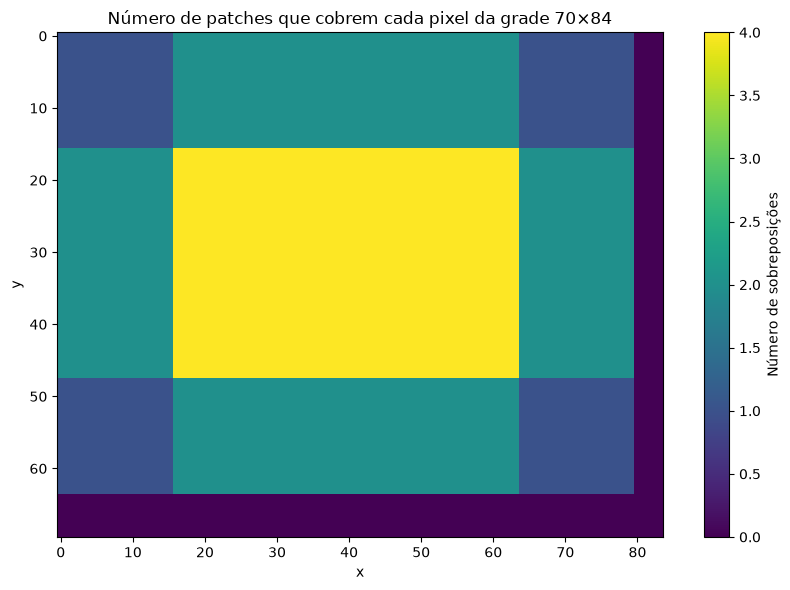

Pixels sem cobertura de patch: 760
Cobertura espacial: 87.07%


In [19]:
coverage_file = QUALITY_DIR / "expected_patch_spatial_coverage.npy"
if coverage_file.exists():
    patch_coverage = np.load(coverage_file)
    fig, ax = plt.subplots(figsize=(9, 6))
    im = ax.imshow(patch_coverage, origin="upper")
    ax.set_title("Número de patches que cobrem cada pixel da grade 70×84")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    fig.colorbar(im, ax=ax, label="Número de sobreposições")
    plt.tight_layout()
    plt.show()

    uncovered = np.argwhere(patch_coverage == 0)
    print("Pixels sem cobertura de patch:", len(uncovered))
    print("Cobertura espacial:", f"{(patch_coverage > 0).mean():.2%}")

### Observação metodológica sobre as bordas

Com o loop atual baseado em `range(0, tamanho - patch_size + 1, stride)`, uma dimensão cujo restante não seja compatível com o stride pode deixar pixels de borda sem cobertura. Isso **não invalida** o dataset, mas precisa ser conhecido ao reconstruir campos completos ou calcular climatologias espaciais a partir dos patches.

Uma alternativa futura seria adicionar explicitamente a última âncora `tamanho - patch_size` para garantir cobertura integral, caso isso seja desejável no desenho experimental.


## 8. Qualidade numérica dos canais


In [20]:
if channel_summary.empty:
    display(Markdown("O auditor foi executado em modo `quick` sem estatísticas numéricas completas."))
else:
    cols = [
        c for c in [
            "kind", "channel_index", "channel", "finite_ratio", "mean", "std", "min", "max",
            "p01", "p05", "p25", "p50", "p75", "p95", "p99",
            "quantile_sample_count", "mean_abs_diff_vs_builder", "std_abs_diff_vs_builder"
        ] if c in channel_summary.columns
    ]
    display(channel_summary[cols])

,kind,channel_index,channel,finite_ratio,mean,std,min,max,p01,p05,p25,p50,p75,p95,p99,quantile_sample_count,mean_abs_diff_vs_builder,std_abs_diff_vs_builder
0,input,0,tcwv,1.0,36.219420,11.297360,4.378057,71.471512,13.909897,18.059224,27.298481,36.180628,45.047571,54.429963,59.059435,200000,1.456120e-06,4.359896e-07
1,input,1,t2m,1.0,296.284935,3.399368,278.038635,312.512421,287.974561,290.821371,294.149963,296.188095,298.372185,302.085912,305.208356,200000,7.841528e-06,8.328239e-09
2,input,2,u10,1.0,-1.047842,2.739994,-14.512887,19.845610,-8.500602,-6.147163,-2.355279,-0.666662,0.359459,3.167854,5.902261,200000,8.464180e-09,9.844724e-08
3,input,3,v10,1.0,0.051507,2.106449,-11.636978,16.759144,-4.638195,-3.155347,-1.334419,-0.081116,1.310487,3.685196,5.816500,200000,1.035120e-09,7.899562e-08
4,input,4,t_850,1.0,288.755047,3.536194,273.789551,301.209442,280.033319,282.449031,286.396141,289.124741,291.444344,293.856084,295.530190,200000,1.151359e-05,6.110154e-08
5,input,5,r_850,1.0,73.732359,17.978214,-0.109382,109.605881,24.039881,40.449390,62.249963,76.067722,87.958031,98.365683,100.144276,200000,1.885980e-06,1.363545e-07
6,input,6,u_850,1.0,1.078007,3.626558,-17.097549,29.568466,-7.050110,-4.430108,-1.292953,0.822650,3.243077,7.356710,11.058766,200000,2.400303e-08,2.373434e-08
7,input,7,v_850,1.0,-1.434992,3.973074,-21.984325,18.171896,-11.092907,-7.755906,-3.991693,-1.603945,1.098554,5.339451,8.172159,200000,8.078490e-09,2.422363e-08
8,input,8,t_500,1.0,265.462980,2.172084,253.418793,272.111359,259.809156,261.546414,264.059776,265.726791,267.057030,268.540652,269.628574,200000,2.503584e-06,7.328690e-08
9,input,9,r_500,1.0,34.107492,31.357926,-5.254326,128.701660,1.365915,2.643603,7.225638,20.815765,58.900643,94.392957,99.698699,200000,1.272083e-06,6.854461e-07


,kind,channel_index,channel,total_count,finite_count,nan_count,posinf_count,neginf_count,finite_ratio
0,input,0,tcwv,1159643136,1159643136,0,0,0,1.0
1,input,1,t2m,1159643136,1159643136,0,0,0,1.0
2,input,2,u10,1159643136,1159643136,0,0,0,1.0
3,input,3,v10,1159643136,1159643136,0,0,0,1.0
4,input,4,t_850,1159643136,1159643136,0,0,0,1.0
5,input,5,r_850,1159643136,1159643136,0,0,0,1.0
6,input,6,u_850,1159643136,1159643136,0,0,0,1.0
7,input,7,v_850,1159643136,1159643136,0,0,0,1.0
8,input,8,t_500,1159643136,1159643136,0,0,0,1.0
9,input,9,r_500,1159643136,1159643136,0,0,0,1.0


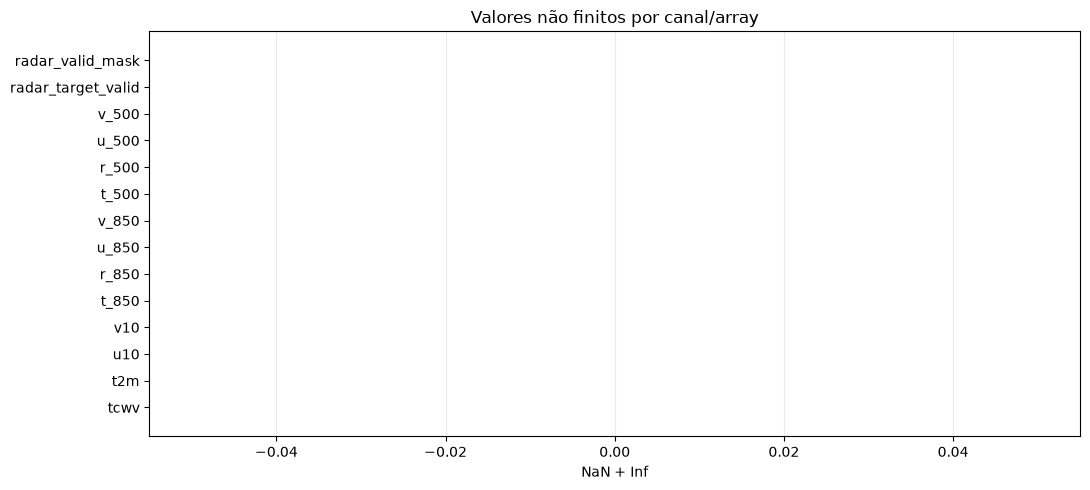

In [21]:
if not missing_data.empty:
    display(missing_data)

    nonfinite = missing_data.copy()
    nonfinite["nonfinite_count"] = (
        nonfinite["nan_count"] + nonfinite["posinf_count"] + nonfinite["neginf_count"]
    )
    fig, ax = plt.subplots(figsize=(11, 5))
    ax.barh(nonfinite["channel"], nonfinite["nonfinite_count"])
    ax.set_xlabel("NaN + Inf")
    ax.set_title("Valores não finitos por canal/array")
    ax.grid(axis="x", alpha=0.25)
    plt.tight_layout()
    plt.show()

No dataset atual, `minimum_input_valid_ratio=1.0` implica que patches com qualquer insuficiência de validade no tensor de entrada deveriam ser rejeitados antes da escrita. Portanto, encontrar NaN/Inf no `input` gravado merece investigação.


## 9. Máscara e integridade do target


In [22]:
mask_info = summary.get("mask", {})
target_info = summary.get("target_integrity", {})

display(pd.DataFrame([mask_info]))
display(pd.DataFrame([target_info]))

if mask_info:
    print("Proporção global de pixels válidos do radar:", f"{mask_info.get('valid_pixel_ratio', float('nan')):.2%}")

,total_values,finite_count,nan_count,posinf_count,neginf_count,valid_pixel_count,valid_pixel_ratio,binary_violation_count
0,1159643136,1159643136,0,0,0,1159643136,1.0,0


,negative_finite_value_count,invalid_mask_region_nonzero_count,nan_count_all_stored_target_pixels,posinf_count_all_stored_target_pixels,neginf_count_all_stored_target_pixels
0,0,0,0,0,0


Proporção global de pixels válidos do radar: 100.00%


### Transformação do alvo registrada no Zarr

O builder grava no atributo/metadata `target_transform = "log1p"`. A seção seguinte verifica de forma independente **o que existe no cache** e, quando o cache está acessível, reproduz numericamente a transformação cache → `target` para uma amostra de patches.


## 10. Semântica do radar: PNG → cache `.npy` → `target` Zarr

A implementação auditada do builder possui uma etapa própria de criação do cache do Radar Sumaré. O código:

1. lê o PNG e converte a imagem para RGB;
2. compara cada pixel às cores configuradas na legenda;
3. escolhe as duas cores de legenda mais próximas em distância Euclidiana RGB;
4. interpola numericamente entre os valores associados a essas duas cores;
5. remapeia o campo para a grade geográfica do radar por índices inteiros `py, px`;
6. grava a grade resultante como `float32` em `YYYYMMDD_HH_MM.npy`;
7. durante a criação dos patches, calcula `mask = isfinite(cache_patch)`;
8. aplica `nan_to_num`, `clip(min=0)` e `log1p` antes de gravar `target`.

**Importante:** o código nomeia o campo como `reflectivity`, porém **não declara a unidade física como dBZ**. O valor físico da legenda deve ser confirmado na documentação/origem do produto radar antes de usar o rótulo `dBZ` em gráficos ou na dissertação.


In [23]:
builder_semantics = radar_semantics.get("builder_semantics", {})
cache_validation = radar_semantics.get("cache_validation", {})
mapping_validation = radar_semantics.get("target_mapping_validation", {})

display(Markdown("### Semântica documentada pelo código do builder"))
display(pd.DataFrame([
    ("Origem", builder_semantics.get("source_format")),
    ("Conversão RGB", builder_semantics.get("rgb_to_numeric_method")),
    ("Campo nomeado no código", builder_semantics.get("physical_field_name_in_builder")),
    ("Unidade física declarada", builder_semantics.get("physical_unit_declared_in_builder")),
    ("dBZ confirmado somente pelo builder?", builder_semantics.get("dbz_confirmed_by_builder_alone")),
    ("dtype do cache", builder_semantics.get("cache_array_dtype")),
    ("Transformação do target", builder_semantics.get("zarr_target_transform")),
    ("Definição da máscara", builder_semantics.get("zarr_mask_definition")),
], columns=["Item", "Valor"]))

display(Markdown("### Legenda RGB incorporada no builder"))
legend_display = radar_legend.copy()
legend_display["RGB"] = legend_display.apply(lambda r: f"({int(r.r)}, {int(r.g)}, {int(r.b)})", axis=1)
display(legend_display[["legend_index", "RGB", "value"]])


### Semântica documentada pelo código do builder

,Item,Valor
0,Origem,PNG converted to RGB
1,Conversão RGB,two nearest configured legend colors in RGB Eu...
2,Campo nomeado no código,reflectivity
3,Unidade física declarada,None
4,dBZ confirmado somente pelo builder?,False
5,dtype do cache,float32
6,Transformação do target,nan_to_num(nan/+-inf -> 0) -> clip(min=0) -> l...
7,Definição da máscara,"isfinite(raw cache patch), before clip/log1p"


### Legenda RGB incorporada no builder

,legend_index,RGB,value
0,0,"(197, 0, 197)",50.0
1,1,"(227, 6, 5)",45.0
2,2,"(255, 112, 0)",40.0
3,3,"(195, 230, 0)",35.0
4,4,"(4, 85, 4)",30.0
5,5,"(19, 122, 19)",25.0
6,6,"(0, 167, 12)",20.0
7,7,"(0, 0, 0)",0.0


,value,target_log1p,expm1_target
7,0.0,0.000000,0.0
6,20.0,3.044522,20.0
5,25.0,3.258097,25.0
4,30.0,3.433987,30.0
3,35.0,3.583519,35.0
2,40.0,3.713572,40.0
1,45.0,3.828641,45.0
0,50.0,3.931826,50.0


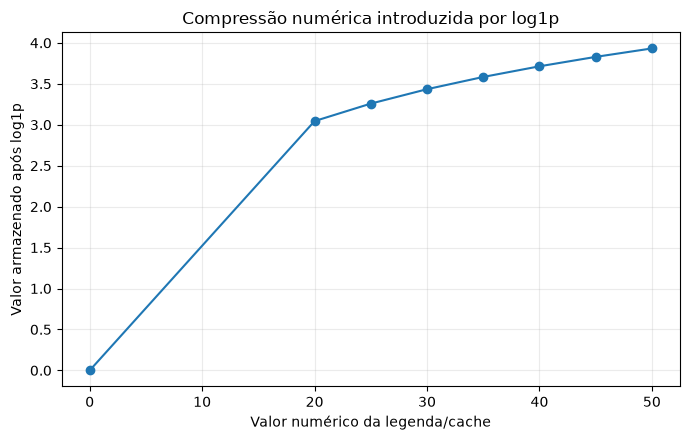

In [24]:
# Relação determinística entre os valores da legenda e o target, caso o cache
# contenha exatamente esses valores e eles sejam não-negativos.
legend_transform = radar_legend[["value"]].copy().sort_values("value")
legend_transform["target_log1p"] = np.log1p(np.clip(legend_transform["value"].astype(float), 0, None))
legend_transform["expm1_target"] = np.expm1(legend_transform["target_log1p"])
display(legend_transform)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(legend_transform["value"], legend_transform["target_log1p"], marker="o")
ax.set_xlabel("Valor numérico da legenda/cache")
ax.set_ylabel("Valor armazenado após log1p")
ax.set_title("Compressão numérica introduzida por log1p")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


### 10.1 Estatísticas amostradas diretamente do cache

O auditor **não percorre todos os arquivos de 2 minutos**. Ele escolhe timestamps distintos que aparecem no Zarr e inspeciona os `.npy` correspondentes. Isso permite verificar `dtype`, shape, faixa numérica, valores negativos/não finitos e possíveis valores fora da faixa da legenda sem enumerar milhões de arquivos.


,status,sampling_basis,requested_files,found_files,missing_files,shape_mismatch_files,sampled_pixel_count,sampled_nonfinite_count,sampled_finite_ratio,sampled_negative_value_count,sampled_below_legend_min_count,sampled_above_legend_max_count,sampled_min,sampled_max,sampled_mean,sampled_std,sampled_p01,sampled_p05,sampled_p25,sampled_p50,sampled_p75,sampled_p95,sampled_p99
0,PASS,distinct timestamps present in Zarr; no full c...,128,128,0,0,752640,0,1.0,0,0,0,0.0,45.0,0.288986,2.748316,0.0,0.0,0.0,0.0,0.0,0.0,20.0


,timestamp,exists,shape,dtype,finite_ratio,min,p01,p50,p95,p99,max,negative_count,below_legend_min_count,above_legend_max_count
0,2011-02-12 12:00:00,True,"(70, 84)",float32,1.0,0.0,0.0,0.0,0.0,0.0,20.000000,0,0,0
1,2011-04-04 13:00:00,True,"(70, 84)",float32,1.0,0.0,0.0,0.0,0.0,20.0,30.000000,0,0,0
2,2011-05-13 15:00:00,True,"(70, 84)",float32,1.0,0.0,0.0,0.0,0.0,0.0,40.000000,0,0,0
3,2011-05-17 03:00:00,True,"(70, 84)",float32,1.0,0.0,0.0,0.0,0.0,0.0,29.040398,0,0,0
4,2011-10-20 08:00:00,True,"(70, 84)",float32,1.0,0.0,0.0,0.0,0.0,0.0,0.000000,0,0,0
5,2011-12-16 03:00:00,True,"(70, 84)",float32,1.0,0.0,0.0,0.0,0.0,0.0,45.000000,0,0,0
6,2012-01-10 00:00:00,True,"(70, 84)",float32,1.0,0.0,0.0,0.0,0.0,0.0,29.222357,0,0,0
7,2012-02-17 07:00:00,True,"(70, 84)",float32,1.0,0.0,0.0,0.0,0.0,0.0,0.000000,0,0,0
8,2012-03-07 03:00:00,True,"(70, 84)",float32,1.0,0.0,0.0,0.0,0.0,0.0,35.000000,0,0,0
9,2012-05-25 12:00:00,True,"(70, 84)",float32,1.0,0.0,0.0,0.0,0.0,0.0,22.743296,0,0,0


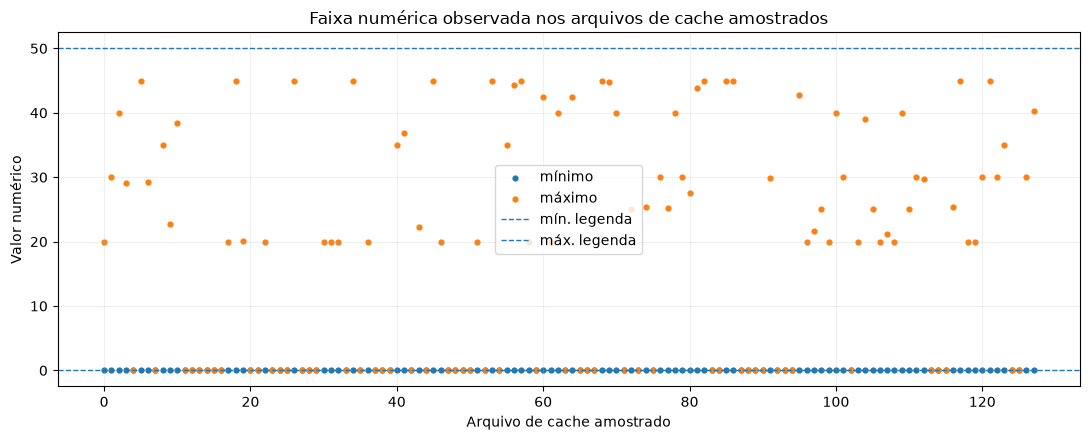

In [25]:
display(pd.DataFrame([cache_validation]))

if radar_cache_stats.empty:
    display(Markdown(
        "⚠️ **A inspeção direta do cache não foi executada.** Informe `--radar-cache-dir` "
        "ou defina `CORRDIFF_RADAR_CACHE_DIR` e rode novamente o auditor."
    ))
else:
    cols = [c for c in [
        "timestamp", "exists", "shape", "dtype", "finite_ratio",
        "min", "p01", "p50", "p95", "p99", "max",
        "negative_count", "below_legend_min_count", "above_legend_max_count"
    ] if c in radar_cache_stats.columns]
    display(radar_cache_stats[cols].head(30))

    present = radar_cache_stats.loc[radar_cache_stats.get("exists", False) == True].copy()
    if not present.empty and {"min", "max"}.issubset(present.columns):
        fig, ax = plt.subplots(figsize=(11, 4.5))
        x = np.arange(len(present))
        ax.scatter(x, present["min"], s=12, label="mínimo")
        ax.scatter(x, present["max"], s=12, label="máximo")
        ax.axhline(radar_legend["value"].min(), linestyle="--", linewidth=1, label="mín. legenda")
        ax.axhline(radar_legend["value"].max(), linestyle="--", linewidth=1, label="máx. legenda")
        ax.set_xlabel("Arquivo de cache amostrado")
        ax.set_ylabel("Valor numérico")
        ax.set_title("Faixa numérica observada nos arquivos de cache amostrados")
        ax.legend()
        ax.grid(alpha=0.2)
        plt.tight_layout()
        plt.show()


### 10.2 Validação direta cache → patch → Zarr

Para amostras do Zarr, o auditor usa `timestamp`, `patch_row` e `patch_col` para abrir o `.npy` original e extrair exatamente a mesma região espacial. Em seguida reproduz:

```python
expected_mask = np.isfinite(cache_patch)
filled = np.nan_to_num(cache_patch, nan=0.0, posinf=0.0, neginf=0.0)
clipped = np.clip(filled, 0.0, None)
expected_target = np.log1p(clipped)
```

Ele compara `expected_target` com `train.zarr/target` e `expected_mask` com `train.zarr/mask`. Também testa `expm1(target)` contra o **cache após o clip**, deixando explícito que valores negativos, caso existam, não podem ser recuperados.


,status,requested_samples,compared_samples,shape_compatible_samples,missing_cache_candidates,absolute_tolerance,max_abs_diff_stored_vs_expected_log1p,max_abs_diff_expm1_vs_clipped_cache,total_mask_mismatch_count,source_negative_values_seen_in_compared_patches,all_compared_samples_match_builder_transform
0,PASS,256,256,256,0,0.000002,0.0,0.000008,0,0,True


,sample_index,timestamp,patch_row,patch_col,raw_cache_min,raw_cache_max,raw_cache_negative_count,stored_target_min,stored_target_max,max_abs_diff_stored_vs_expected_log1p,max_abs_diff_expm1_vs_clipped_cache,mask_mismatch_count,mapping_matches_within_tolerance
0,873111,2021-03-06 02:00:00,0,48,0.0,0.000000,0,0.0,0.000000,0.0,0.000000,0,True
1,851097,2020-12-07 07:00:00,32,16,0.0,36.238968,0,0.0,3.617356,0.0,0.000004,0,True
2,523052,2016-11-14 03:00:00,32,0,0.0,20.000000,0,0.0,3.044523,0.0,0.000002,0,True
3,1006002,2022-10-14 19:00:00,16,32,0.0,20.000000,0,0.0,3.044523,0.0,0.000002,0,True
4,618851,2017-12-18 03:00:00,32,48,0.0,0.000000,0,0.0,0.000000,0.0,0.000000,0,True
5,1085784,2023-10-25 19:00:00,0,0,0.0,0.000000,0,0.0,0.000000,0.0,0.000000,0,True
6,906125,2021-07-18 09:00:00,16,16,0.0,0.000000,0,0.0,0.000000,0.0,0.000000,0,True
7,145439,2012-11-11 04:00:00,32,48,0.0,20.000000,0,0.0,3.044523,0.0,0.000002,0,True
8,382387,2015-04-29 05:00:00,16,48,0.0,0.000000,0,0.0,0.000000,0.0,0.000000,0,True
9,464410,2016-03-24 14:00:00,32,32,0.0,0.000000,0,0.0,0.000000,0.0,0.000000,0,True


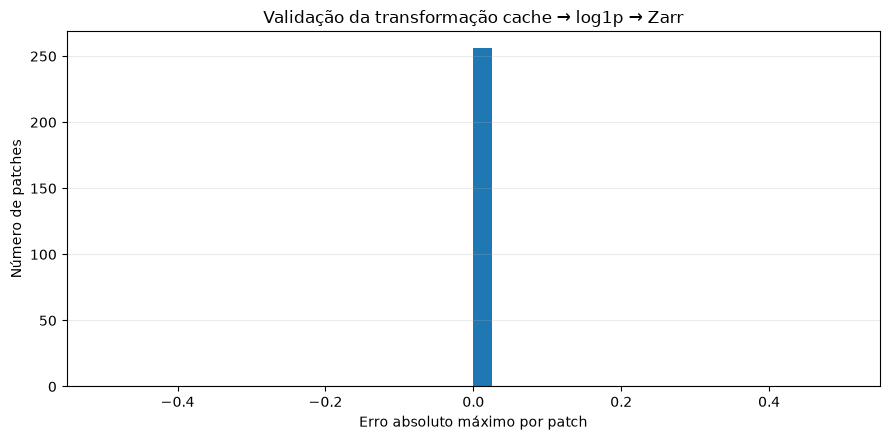

In [26]:
display(pd.DataFrame([mapping_validation]))

if radar_mapping.empty:
    display(Markdown("⚠️ Não há resultados de validação direta cache → Zarr."))
else:
    cols = [c for c in [
        "sample_index", "timestamp", "patch_row", "patch_col",
        "raw_cache_min", "raw_cache_max", "raw_cache_negative_count",
        "stored_target_min", "stored_target_max",
        "max_abs_diff_stored_vs_expected_log1p",
        "max_abs_diff_expm1_vs_clipped_cache",
        "mask_mismatch_count", "mapping_matches_within_tolerance"
    ] if c in radar_mapping.columns]
    display(radar_mapping[cols].head(30))

    valid = radar_mapping.loc[radar_mapping.get("shape_match", True) == True].copy()
    if not valid.empty and "max_abs_diff_stored_vs_expected_log1p" in valid.columns:
        fig, ax = plt.subplots(figsize=(9, 4.5))
        ax.hist(valid["max_abs_diff_stored_vs_expected_log1p"].dropna(), bins=40)
        ax.set_xlabel("Erro absoluto máximo por patch")
        ax.set_ylabel("Número de patches")
        ax.set_title("Validação da transformação cache → log1p → Zarr")
        ax.grid(axis="y", alpha=0.25)
        plt.tight_layout()
        plt.show()


### 10.3 Conclusão semântica a registrar

Se `target_mapping_validation.status == PASS`, podemos afirmar a partir do **código + verificação empírica** que:

- o cache `.npy` contém valores numéricos derivados da legenda RGB do produto radar;
- esses valores são gravados em `float32` na grade do radar;
- o `target` do Zarr não contém o cache bruto;
- para valores finitos e não negativos, `target = log1p(cache)`;
- `expm1(target)` retorna o valor do cache **após o `clip(min=0)`**;
- valores negativos do cache, se existirem, são convertidos para zero e sua magnitude original é perdida;
- a máscara é definida pela finitude do cache **antes** do `clip`;
- **a unidade física (`dBZ` ou outra) não é declarada pelo builder** e deve ser confirmada na fonte do produto de radar.

Essa distinção é importante para a Fase 1: podemos analisar matematicamente a distribuição do `target`, mas só devemos rotular valores como `dBZ` depois de comprovar a unidade original da legenda.


## 11. Contadores do builder


In [27]:
builder_counters = summary.get("builder_counters", {})
if builder_counters:
    counters_df = pd.DataFrame(
        sorted(builder_counters.items()), columns=["contador", "valor"]
    )
    display(counters_df)
else:
    print("metadata.json não contém counters do builder.")

,contador,valor
0,invalid_radar,3
1,missing_era5,0
2,missing_radar,28361
3,patches_rejected_input,0
4,patches_rejected_radar,0
5,patches_written,1132464
6,shape_mismatch,0
7,timestamps_processed,94372
8,timestamps_total,122736


## 12. Diagnóstico automático para avançar à Fase 1


In [28]:
checks = []

def add_check(name, ok, detail):
    checks.append({"checagem": name, "status": "OK" if ok else "REVISAR", "detalhe": detail})

add_check(
    "Dimensões do Zarr",
    bool(dataset.get("sample_dimension_consistent")),
    str(dataset.get("sample_dimensions")),
)
add_check(
    "12 canais ERA5",
    dataset.get("num_channels") == 12,
    f"C={dataset.get('num_channels')} | {dataset.get('channels')}",
)
add_check(
    "Grade do radar 70×84",
    config.get("radar_grid_shape") == [70, 84],
    str(config.get("radar_grid_shape")),
)
add_check(
    "Patch 32 / stride 16",
    config.get("patch_size") == 32 and config.get("stride") == 16,
    f"patch={config.get('patch_size')}, stride={config.get('stride')}",
)
add_check(
    "Cobertura temporal conhecida",
    temporal_summary.get("coverage_ratio") is not None,
    f"coverage={temporal_summary.get('coverage_ratio')}",
)

if not missing_data.empty:
    input_rows = missing_data.loc[missing_data["kind"] == "input"]
    input_nonfinite = int(
        input_rows[["nan_count", "posinf_count", "neginf_count"]].sum().sum()
    )
    add_check("Inputs sem NaN/Inf", input_nonfinite == 0, f"nonfinite={input_nonfinite}")

if summary.get("mask"):
    add_check(
        "Máscara binária",
        summary["mask"].get("binary_violation_count", 0) == 0,
        f"violations={summary['mask'].get('binary_violation_count')}",
    )

mapping_status = radar_semantics.get("target_mapping_validation", {}).get("status")
if mapping_status not in (None, "SKIPPED"):
    add_check(
        "Cache → target reproduz o builder",
        mapping_status == "PASS",
        str(radar_semantics.get("target_mapping_validation", {})),
    )
else:
    add_check(
        "Cache → target foi validado diretamente",
        False,
        "SKIPPED — rode novamente com --radar-cache-dir para fechar a semântica do alvo.",
    )

add_check(
    "Unidade física do radar documentada",
    builder_semantics.get("physical_unit_declared_in_builder") is not None,
    "O builder não declara dBZ; confirmar na documentação/origem da legenda do produto radar.",
)

checks_df = pd.DataFrame(checks)
display(checks_df)

if (checks_df["status"] == "REVISAR").any() or summary.get("warnings_count", 0) > 0:
    display(Markdown("### Resultado: **há itens a revisar antes da Fase 1**"))
else:
    display(Markdown("### Resultado: **dataset apto a avançar para a Fase 1 — análise univariada**"))


,checagem,status,detalhe
0,Dimensões do Zarr,OK,"{'input': 1132464, 'target': 1132464, 'mask': ..."
1,12 canais ERA5,OK,"C=12 | ['tcwv', 't2m', 'u10', 'v10', 't_850', ..."
2,Grade do radar 70×84,OK,"[70, 84]"
3,Patch 32 / stride 16,OK,"patch=32, stride=16"
4,Cobertura temporal conhecida,OK,coverage=0.7689023595359145
5,Inputs sem NaN/Inf,OK,nonfinite=0
6,Máscara binária,OK,violations=0
7,Cache → target reproduz o builder,OK,"{'status': 'PASS', 'requested_samples': 256, '..."
8,Unidade física do radar documentada,REVISAR,O builder não declara dBZ; confirmar na docume...


### Resultado: **há itens a revisar antes da Fase 1**

## 13. O que levamos para a próxima fase

Ao concluir esta auditoria, registre no texto da dissertação:

1. período temporal efetivamente disponível;
2. número de timestamps e patches válidos;
3. cobertura por ano/mês/hora;
4. ordem exata dos 12 canais;
5. resolução espacial e temporal;
6. geometria e cobertura dos patches;
7. percentual de pixels válidos do radar;
8. presença/ausência de valores não finitos;
9. legenda numérica implementada na criação do cache;
10. faixa efetivamente observada nos `.npy` amostrados;
11. validação direta da transformação cache → `target`;
12. efeito do `clip(min=0)` e eventual perda de valores negativos;
13. situação da unidade física do radar — **não declarada no builder e pendente de confirmação externa**;
14. qualquer período ou posição espacial sub-representada.

A **Fase 1** deverá então estudar as distribuições univariadas em maior detalhe: histogramas, ECDF, quantis, assimetria, curtose e dependência sazonal. Para o radar, mantenha duas escalas explicitamente separadas quando necessário: `target` armazenado e `expm1(target)` (domínio pós-clip do cache). Não use o rótulo `dBZ` até a unidade original da legenda estar documentada.
